In [27]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Dataset
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import numpy as np

from google.colab import files, drive

In [2]:
# Hyperparameters
layers = [3, 64, 64, 64, 1]
lr = 1e-3
batch_size = 32
epochs = 50

In [3]:
def sdf_box(p, center, half_extents):
    """
    SDF for an axis-aligned box.

    Parameters
    ----------
    p : (N, 2) array of points to evaluate
    center : (2,) array-like — center of the box e.g. [0.0, 0.0]
    half_extents : (2,) array-like — half the width and height of the box e.g. [0.5, 0.5]
    """
    q = np.abs(p - center) - half_extents
    return np.linalg.norm(np.maximum(q, 0), axis=-1) + np.minimum(np.max(q, axis=-1), 0)


def sdf_t_block(p, bar_width, bar_height, stem_width, stem_height):
    """
    T-shape as union of two boxes.
    Origin is at the center of the full bounding box.

        ┌─────────────┐  ↑
        │   top bar   │  bar_height
        └────┬───┬────┘  ↓
             │ s │  ↑
             │ t │  stem_height
             │ e │
             │ m │  ↓
             └───┘
    """
    bar_center = np.array([0.0, stem_height / 2])
    stem_center = np.array([0.0, -bar_height / 2])

    overlap = 0.05
    bar = sdf_box(p, bar_center, np.array([bar_width / 2, bar_height / 2]))
    stem = sdf_box(
        p, 
        stem_center + np.array([0.0, overlap / 2]), 
        np.array([stem_width / 2, stem_height / 2 + overlap / 2])
    )

    return np.minimum(bar, stem)

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Plate parameters
size = 2.0
t_max = 5.0
alpha = 0.01

SDF = lambda coords: sdf_t_block(
    coords, bar_width=1.5, bar_height=0.385, stem_width=0.385, stem_height=1.0
)

Using device: cuda


In [5]:
!wget -O T_plate.csv https://raw.githubusercontent.com/brcktn/Inverse-Heat-PINN/main/training_data/T_plate.csv

class CSVDataset(Dataset):
    def __init__(self, csv_file):
        data = pd.read_csv(csv_file).values.astype(np.float32)
        self.X = torch.from_numpy(data[:, 1:4])  # coords (x, y, t)
        self.y = torch.from_numpy(data[:, 4:])   # temperature

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = CSVDataset('T_plate.csv')
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# next(iter(dataloader))

--2026-04-15 20:14:38--  https://raw.githubusercontent.com/brcktn/Inverse-Heat-PINN/main/training_data/T_plate.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 615246 (601K) [text/plain]
Saving to: ‘T_plate.csv’

T_plate.csv         100%[===================>] 600.83K  --.-KB/s    in 0.03s   

2026-04-15 20:14:38 (19.8 MB/s) - ‘T_plate.csv’ saved [615246/615246]



In [6]:
class HeatPINN(nn.Module):
    def __init__(self, layers):
        """
        Parameters
        ----------
        layers : list of int
            A list of integers specifying the number of neurons in each layer
        """
        super(HeatPINN, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))
            if i < len(layers) - 2:
                self.layers.append(nn.SiLU())

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [7]:
def sample_points(num_points, t_max, SDF):
    """
    Sample points in space and time within the domain defined by the SDF.
    
    Parameters
    ----------
    num_points : int
        Total number of points to sample
    t_max : float
        Maximum time to sample
    SDF : function
        A function that takes (N, 2) coordinates and returns their SDF values
    """
    points = []
    while len(points) < num_points:
        x = np.random.uniform(-size/2, size/2)
        y = np.random.uniform(-size/2, size/2)
        t = np.random.uniform(0, t_max)
        if SDF(np.array([[x, y]])) < 0:  # Inside the domain
            points.append([x, y, t])
    return torch.tensor(points, dtype=torch.float32)


def sample_boundary_points(num_points, t_max, SDF, eps=1e-4, steps=10):
    """
    Sample points precisely on the boundary of the domain defined by the SDF
    using gradient descent projection.
    
    Parameters
    ----------
    num_points : int
        Total number of points to sample
    t_max : float
        Maximum time to sample
    SDF : function
        A function that takes (N, 2) coordinates and returns their SDF values
    """
    # Start with random points in domain for spatial coords (x,y) and time (t)
    pts_xy = np.random.uniform(-size/2, size/2, (num_points * 10, 2))
    pts_t = np.random.uniform(0, t_max, (num_points * 10, 1))
    
    # Project onto surface via numerical gradient descent on the SDF
    # (Since the SDF is currently implemented with NumPy, we use numerical gradients)
    dx = 1e-5
    for _ in range(steps):
        f = SDF(pts_xy)
        
        grad_x = (SDF(pts_xy + np.array([dx, 0])) - SDF(pts_xy - np.array([dx, 0]))) / (2 * dx)
        grad_y = (SDF(pts_xy + np.array([0, dx])) - SDF(pts_xy - np.array([0, dx]))) / (2 * dx)
        grad = np.stack([grad_x, grad_y], axis=-1)
        
        grad_norm = np.linalg.norm(grad, axis=-1, keepdims=True)
        pts_xy -= np.expand_dims(f, -1) * grad / (grad_norm + 1e-8)
    
    # Keep points that converged precisely to the surface
    f = SDF(pts_xy)
    on_surface = np.abs(f) < eps
    
    pts_xy_surface = pts_xy[on_surface]
    pts_t_surface = pts_t[on_surface]
    
    points = np.concatenate([pts_xy_surface, pts_t_surface], axis=-1)
    return torch.tensor(points[:num_points], dtype=torch.float32)

In [8]:
def data_loss(model, points, temperatures):
    """
    MSE loss between model predictions and observed temperatures at given points.

    Parameters
    ----------
    model : nn.Module
        The PINN model
    points : (N, 3) tensor
        The (x, y, t) coordinates of the observed data points
    temperatures : (N, 1) tensor
        The observed temperatures at the given points

    Returns
    -------
    torch.Tensor
        The computed MSE loss
    """
    x_batch = points.to(device)
    y_batch = temperatures.to(device)
    pred = model(x_batch)
    return nn.MSELoss()(pred, y_batch)


def physics_loss(model, points, alpha):
    """
    Physics loss enforcing the heat equation at given points.

    Parameters
    ----------
    model : nn.Module
        The PINN model
    points : (N, 3) tensor
        The (x, y, t) coordinates of the collocation points
    alpha : float
        Thermal diffusivity constant

    Returns
    -------
    torch.Tensor
        The computed physics loss
    """
    points = points.to(device).requires_grad_(True)
    pred = model(points)
    
    # Gradients
    u_t = torch.autograd.grad(pred, points, grad_outputs=torch.ones_like(pred), create_graph=True)[0][:, 2:3]
    u_x = torch.autograd.grad(pred, points, grad_outputs=torch.ones_like(pred), create_graph=True)[0][:, 0:1]
    u_y = torch.autograd.grad(pred, points, grad_outputs=torch.ones_like(pred), create_graph=True)[0][:, 1:2]
    
    u_xx = torch.autograd.grad(u_x, points, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = torch.autograd.grad(u_y, points, grad_outputs=torch.ones_like(u_y), create_graph=True)[0][:, 1:2]

    residual = u_t - alpha * (u_xx + u_yy)
    return torch.mean(residual**2)


def boundary_loss(model, points):
    """
    Loss enforcing boundary conditions at given points.

    Parameters
    ----------
    model : nn.Module
        The PINN model
    points : (N, 3) tensor
        The (x, y, t) coordinates of the boundary points

    Returns
    -------
    torch.Tensor
        The computed boundary loss
    """
    points = points.to(device)
    pred = model(points)
    return torch.mean(pred**2)  # Assuming zero temperature on the boundary

In [9]:
def train(model, dataloader, optimizer):
    import time
    model.train()
    for epoch in range(epochs):
        epoch_start = time.time()
        total_loss = 0.0
        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_bound_loss = 0.0

        for points, temperatures in dataloader:
            optimizer.zero_grad()
            
            # Sample collocation points for physics and boundary loss
            physics_points = sample_points(batch_size, t_max, SDF)
            boundary_points = sample_boundary_points(batch_size, t_max, SDF)

            # Compute loss
            d_loss = data_loss(model, points, temperatures)
            p_loss = physics_loss(model, physics_points, alpha)
            b_loss = boundary_loss(model, boundary_points)
            loss = d_loss + p_loss + b_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_data_loss += d_loss.item()
            total_phys_loss += p_loss.item()
            total_bound_loss += b_loss.item()

        epoch_time = time.time() - epoch_start
        avg_loss = total_loss / len(dataloader)
        avg_data_loss = total_data_loss / len(dataloader)
        avg_phys_loss = total_phys_loss / len(dataloader)
        avg_bound_loss = total_bound_loss / len(dataloader)

        print(f"Epoch {epoch+1:03d}/{epochs}, Loss: {avg_loss:.6f}, Data Loss: {avg_data_loss:.6f}, Phys Loss: {avg_phys_loss:.6f}, Bound Loss: {avg_bound_loss:.6f}, Time: {epoch_time:.2f}s")



In [10]:
model = HeatPINN(layers).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train(model, dataloader, optimizer)

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 001/50, Loss: 370.535804, Data Loss: 253.349771, Phys Loss: 16.678764, Bound Loss: 100.507268, Time: 15.12s
Epoch 002/50, Loss: 255.726113, Data Loss: 131.707274, Phys Loss: 19.841839, Bound Loss: 104.176999, Time: 13.80s
Epoch 003/50, Loss: 136.169098, Data Loss: 57.723275, Phys Loss: 19.714148, Bound Loss: 58.731675, Time: 13.83s
Epoch 004/50, Loss: 62.075232, Data Loss: 18.066406, Phys Loss: 18.909041, Bound Loss: 25.099785, Time: 13.58s
Epoch 005/50, Loss: 39.723231, Data Loss: 8.186557, Phys Loss: 13.541046, Bound Loss: 17.995627, Time: 13.64s
Epoch 006/50, Loss: 30.767454, Data Loss: 5.345457, Phys Loss: 11.304983, Bound Loss: 14.117015, Time: 13.59s
Epoch 007/50, Loss: 23.463003, Data Loss: 3.623116, Phys Loss: 9.387625, Bound Loss: 10.452262, Time: 13.90s
Epoch 008/50, Loss: 19.056593, Data Loss: 2.761347, Phys Loss: 7.884508, Bound Loss: 8.410738, Time: 14.61s
Epoch 009/50, Loss: 16.756334, Data Loss: 2.360745, Phys Loss: 7.139062, Bound Loss: 7.256527, Time: 13.48s
Epoc

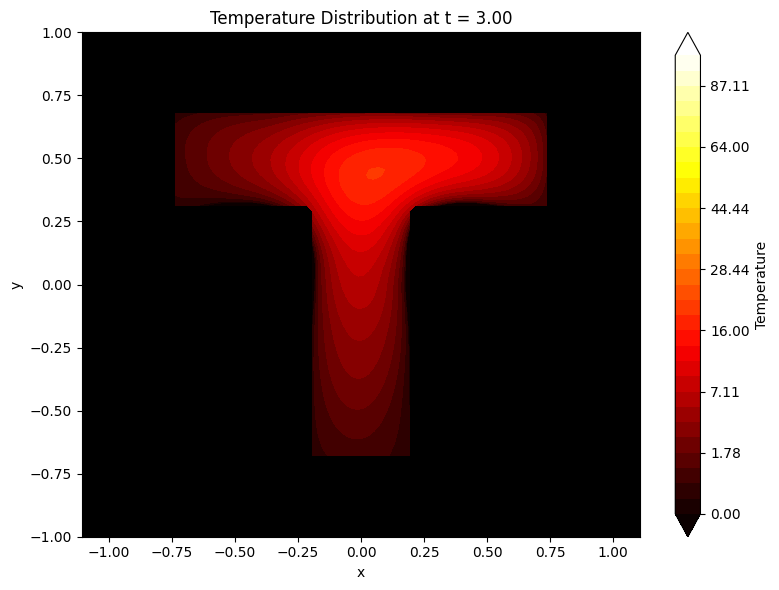

In [26]:
import matplotlib.colors as colors

def plot_heatmap(model, t, size=2.5, resolution=100):
    """
    Plot a heatmap of the temperature distribution at a given time.
    
    Parameters
    ----------
    model : nn.Module
        The trained PINN model.
    t : float
        The time at which to plot the temperature distribution.
    size : float
        The size of the spatial domain (length of the plate).
    resolution : int
        The number of points in each spatial dimension for the grid.
    """
    model.eval()
    
    # Create a grid of (x, y) points
    x = torch.linspace(-size/2, size/2, resolution)
    y = torch.linspace(-size/2, size/2, resolution)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    
    # Flatten and create input tensor with constant time
    x_flat = X.flatten().unsqueeze(1)
    y_flat = Y.flatten().unsqueeze(1)
    t_tensor = torch.full_like(x_flat, t)
    
    points = torch.cat([x_flat, y_flat, t_tensor], dim=1).to(device)
    
    # Get predictions
    with torch.no_grad():
        u = model(points)
    
    # Reshape to grid
    U = u.reshape(resolution, resolution).cpu().numpy()
    
    # Mask values outside the SDF geometry
    coords = np.stack([X.flatten().numpy(), Y.flatten().numpy()], axis=-1)
    sdf_vals = SDF(coords).reshape(resolution, resolution)
    U[sdf_vals > 0] = np.nan  # Set points outside the boundary to NaN
    
    # Fix the scale to always range from 0 to 100
    vmin = 0.0
    vmax = 100.0
    
    # Configure colormap to render NaN values (outside boundary) as black
    cmap_obj = plt.get_cmap('hot').copy()
    cmap_obj.set_bad(color='black')
    
    # Plot
    plt.figure(figsize=(8, 6), dpi=100)
    # Set axis background to black so the transparent NaN contours appear black
    plt.gca().set_facecolor('black')
    
    # Use non-linear levels packed closer together at the bottom to increase low-temperature visibility
    levels = (np.linspace(0, 1, 31) ** 2) * vmax
    
    # We apply a PowerNorm using gamma < 1 to dynamically spread the colors over the lower values
    norm = colors.PowerNorm(gamma=0.5, vmin=vmin, vmax=vmax)
    
    plt.contourf(X.numpy(), Y.numpy(), U, levels=levels, cmap=cmap_obj, norm=norm, extend='both')
    plt.colorbar(label='Temperature')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Temperature Distribution at t = {t:.2f}')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    model.train()

plot_heatmap(model, t=3, size=size, resolution=100)

In [30]:
drive.mount('/content/drive')
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
torch.save(model.state_dict(), f'/content/drive/My Drive/Heat PINN weights/heat_pinn_model_sdf_T_{timestamp}.pth')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
